# Kerchunk vs netCDF Read Performance Across CMIP Frequencies

Kerchunk read performance is largely insensitive to dataset fragmentation, while native netCDF read time degrades rapidly as file count and temporal frequency increase.

**Overview**

- Compares read performance of kerchunk references and native netCDF files across CMIP frequencies.
- Uses per-dataset measurements and frequency-level aggregates to examine scaling with dataset fragmentation and temporal resolution.

**Key findings**

- NetCDF read time increases rapidly with file count and temporal frequency, spanning multiple orders of magnitude.
- Kerchunk read time scales much more favorably and shows weak sensitivity to dataset fragmentation.
- The performance gap between kerchunk and netCDF widens substantially at higher temporal frequencies.
- A small number (~10) of 3-hourly datasets show worse kerchunk performance than native netCDF, specifically when the time dimension is very large and appears last (e.g., `{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 295120}`).

**Conclusion**

- Dataset fragmentation is a dominant driver of native netCDF read performance degradation.
- Kerchunk effectively decouples read performance from file count, providing more stable and predictable read times across CMIP frequencies.
- Kerchunk is particularly advantageous for high-frequency, multi-file CMIP datasets.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
from IPython.display import HTML

# Prevent truncation of strings
pd.set_option("display.max_colwidth", None)
# Display floats with two decimal places
pd.options.display.float_format = "{:.2f}".format

## View Raw Metrics


In [2]:
df_raw = pd.read_csv(
    "riotai/results/20260126_130127/kerchunk_vs_netcdf_raw_20260126_130127.csv"
)

# Add a new column for the difference between kerchunk_time and netcdf_time
df_raw["time_difference"] = df_raw["kerchunk_time"] - df_raw["netcdf_time"]

HTML(
    f"""
<div style="height:400px; overflow-y:scroll;">
    {df_raw.to_html(max_rows=None, max_cols=None, notebook=True)}
</div>
"""
)

,frequency,json,num_netcdf_files,timesteps,dims,kerchunk_time,netcdf_time,time_difference
0,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/mon/CMIP6.CMIP.CNRM-CERFACS.CNRM-CM6-1.historical.r14i1p1f2.Amon.tas.gr.v20191004.kerchunk.json,1,1980,"{'time': 1980, 'lat': 128, 'lon': 256, 'axis_nbounds': 2}",0.52,0.17,0.35
1,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp119/mon/CMIP6.ScenarioMIP.IPSL.IPSL-CM6A-LR.ssp119.r6i1p1f1.Amon.tas.gr.v20191122.kerchunk.json,1,1032,"{'time': 1032, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.70,0.24,0.47
2,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/mon/CMIP6.HighResMIP.ECMWF.ECMWF-IFS-HR.highresSST-present.r5i1p1f1.Amon.pr.gr.v20181119.kerchunk.json,50,618,"{'lat': 361, 'bnds': 2, 'lon': 720, 'time': 618}",0.67,4.43,-3.76
3,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp126/mon/CMIP6.ScenarioMIP.EC-Earth-Consortium.EC-Earth3.ssp126.r139i1p1f1.Amon.tas.gr.v20210615.kerchunk.json,86,1032,"{'lat': 256, 'bnds': 2, 'lon': 512, 'time': 1032}",0.67,7.60,-6.93
4,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp119/mon/CMIP6.ScenarioMIP.EC-Earth-Consortium.EC-Earth3.ssp119.r114i1p1f1.Amon.tas.gr.v20200412.kerchunk.json,86,1032,"{'lat': 256, 'bnds': 2, 'lon': 512, 'time': 1032}",0.29,7.76,-7.47
5,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/ta/piControl/mon/CMIP6.CMIP.E3SM-Project.E3SM-1-0.piControl.r1i1p1f1.Amon.ta.gr.v20220109.kerchunk.json,20,6000,"{'lat': 180, 'bnds': 2, 'lon': 360, 'time': 6000, 'plev': 19}",0.32,4.85,-4.53
6,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp370/mon/CMIP6.ScenarioMIP.IPSL.IPSL-CM6A-LR.ssp370.r1i1p1f1.Amon.tas.gr.v20190119.kerchunk.json,1,1032,"{'time': 1032, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.29,0.23,0.06
7,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/mon/CMIP6.HighResMIP.MIROC.NICAM16-9S.highresSST-present.r1i1p1f1.Amon.pr.gr.v20190830.kerchunk.json,11,132,"{'lat': 1280, 'bnds': 2, 'lon': 2560, 'time': 132}",0.20,1.32,-1.11
8,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/mon/CMIP6.HighResMIP.IPSL.IPSL-CM6A-ATM-HR.highresSST-present.r1i1p1f1.Amon.pr.gr.v20190122.kerchunk.json,1,780,"{'time': 780, 'lat': 361, 'lon': 512, 'axis_nbounds': 2}",0.24,0.56,-0.32
9,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/ta/historical/mon/CMIP6.CMIP.EC-Earth-Consortium.EC-Earth3.historical.r143i1p1f1.Amon.ta.gr.v20200412.kerchunk.json,45,540,"{'lat': 256, 'bnds': 2, 'lon': 512, 'time': 540, 'plev': 19}",0.32,6.08,-5.76


### Longest Kerchunk Runtimes (Outliers)

**Observation:**

- Cases where kerchunk performs worse than netCDF are all 3-hourly datasets with extremely large time dimensions appearing last (e.g., `{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 295120}`).

**Interpretation:**

- These outliers suggest increased kerchunk setup cost for datasets with very large, finely chunked time axes, independent of file count.

**Next steps:**

- Further investigate the impact of time-dimension size, chunking, and dimension order on kerchunk performance.


In [13]:
df_raw_sorted = df_raw.sort_values(by="kerchunk_time", ascending=False)

HTML(
    f"""
<div style="height:400px; overflow-y:scroll;">
    {df_raw_sorted.head(n=10).to_html(max_rows=None, max_cols=None, notebook=True)}
</div>
"""
)

,frequency,json,num_netcdf_files,timesteps,dims,kerchunk_time,netcdf_time,time_difference
127,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/control-1950/hr-misc/CMIP6.HighResMIP.EC-Earth-Consortium.EC-Earth3P-HR.control-1950.r2i1p2f1.3hr.pr.gr.v20190722.kerchunk.json,101,295120,"{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 295120}",69.84,50.54,19.30
101,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/control-1950/hr-misc/CMIP6.HighResMIP.EC-Earth-Consortium.EC-Earth3P-HR.control-1950.r1i1p2f1.3hr.pr.gr.v20181119.kerchunk.json,100,292200,"{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 292200}",69.24,49.71,19.53
105,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/hist-1950/hr-misc/CMIP6.HighResMIP.EC-Earth-Consortium.EC-Earth3P-HR.hist-1950.r2i1p2f1.3hr.pr.gr.v20190625.kerchunk.json,65,189928,"{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 189928}",45.85,27.76,18.09
100,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/hr-misc/CMIP6.HighResMIP.EC-Earth-Consortium.EC-Earth3P-HR.highresSST-present.r3i1p1f1.3hr.pr.gr.v20190509.kerchunk.json,65,189928,"{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 189928}",43.99,27.50,16.49
119,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/hist-1950/hr-misc/CMIP6.HighResMIP.EC-Earth-Consortium.EC-Earth3P-HR.hist-1950.r1i1p2f1.3hr.pr.gr.v20181212.kerchunk.json,65,189927,"{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 189927}",42.91,30.00,12.91
104,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-future/hr-misc/CMIP6.HighResMIP.EC-Earth-Consortium.EC-Earth3P-HR.highresSST-future.r1i1p1f1.3hr.pr.gr.v20190514.kerchunk.json,35,102272,"{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 102272}",24.31,19.41,4.90
93,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-future/hr-misc/CMIP6.HighResMIP.EC-Earth-Consortium.EC-Earth3P-HR.highresSST-future.r3i1p1f1.3hr.pr.gr.v20190713.kerchunk.json,36,105192,"{'lat': 512, 'bnds': 2, 'lon': 1024, 'time': 105192}",23.94,17.20,6.74
85,AERhr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/hr-misc/CMIP6.CMIP.CNRM-CERFACS.CNRM-CM6-1.historical.r5i1p1f2.AERhr.tas.gr.v20190125.kerchunk.json,33,1446360,"{'time': 1446360, 'lat': 128, 'lon': 256, 'axis_nbounds': 2}",19.06,251.56,-232.50
110,3hr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/piControl/hr-misc/CMIP6.CMIP.IPSL.IPSL-CM6A-LR.piControl.r1i1p1f1.3hr.tas.gr.v20180802.kerchunk.json,5,1402528,"{'time': 1402528, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",18.84,247.64,-228.81
80,AERhr,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/hr-misc/CMIP6.CMIP.CNRM-CERFACS.CNRM-CM6-1.historical.r2i1p1f2.AERhr.tas.gr.v20181126.kerchunk.json,33,1446360,"{'time': 1446360, 'lat': 128, 'lon': 256, 'axis_nbounds': 2}",18.65,227.70,-209.05


## Raw Per-Dataset Performance Metrics

The following plots use per-dataset measurements to examine how kerchunk and netCDF read performance scale with dataset structure (file count and frequency).


### Plot 1 - Scaling of Kerchunk vs netCDF Read Time Across CMIP Frequencies


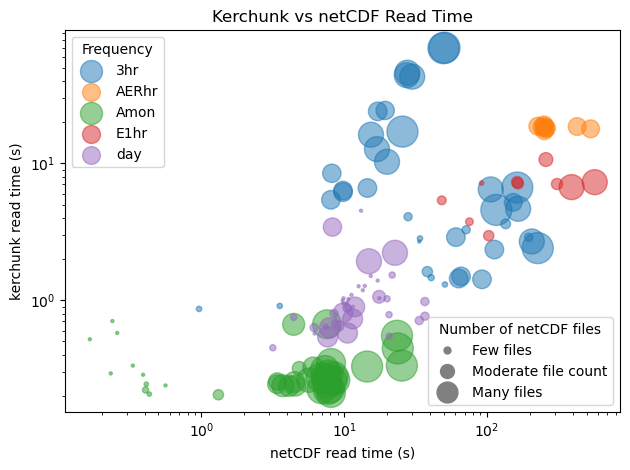

In [4]:
fig, ax = plt.subplots()

freqs = sorted(df_raw["frequency"].unique())
colors = plt.cm.tab10(range(len(freqs)))
color_map = dict(zip(freqs, colors))

for freq in freqs:
    subset = df_raw[df_raw["frequency"] == freq]

    sizes = subset["num_netcdf_files"].clip(upper=100) * 5

    ax.scatter(
        subset["netcdf_time"],
        subset["kerchunk_time"],
        s=sizes,
        color=color_map[freq],
        alpha=0.5,
        label=freq,
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("netCDF read time (s)")
ax.set_ylabel("kerchunk read time (s)")
ax.set_title("Kerchunk vs netCDF Read Time")

# Frequency legend
freq_legend = ax.legend(title="Frequency", loc="upper left")
ax.add_artist(freq_legend)

# Size legend
size_handles = [
    mlines.Line2D(
        [],
        [],
        color="gray",
        marker="o",
        linestyle="None",
        markersize=5,
        label="Few files",
    ),
    mlines.Line2D(
        [],
        [],
        color="gray",
        marker="o",
        linestyle="None",
        markersize=10,
        label="Moderate file count",
    ),
    mlines.Line2D(
        [],
        [],
        color="gray",
        marker="o",
        linestyle="None",
        markersize=15,
        label="Many files",
    ),
]

ax.legend(handles=size_handles, title="Number of netCDF files", loc="lower right")

plt.tight_layout()
plt.show()

**Key observations:**

- NetCDF read time spans multiple orders of magnitude and increases sharply with dataset size and fragmentation.
- Kerchunk read time scales much more slowly than netCDF across the same datasets.
- Higher-frequency datasets occupy systematically higher read-time regimes.
- As fragmentation increases, the performance gap between kerchunk and netCDF widens.

**Takeaway:**
Across CMIP frequencies, netCDF read performance degrades rapidly with increasing fragmentation and temporal resolution, while kerchunk scales more favorably, yielding a growing performance advantage for highly fragmented, high-frequency datasets.


### Plot 2 - Kerchunk Read Time vs Number of netCDF Files (log scale)


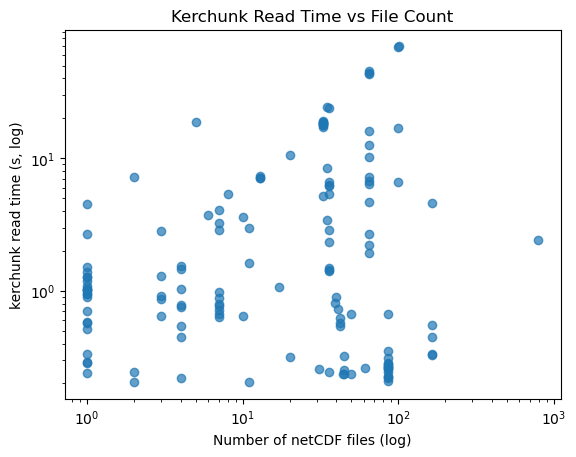

In [5]:
fig, ax = plt.subplots()

ax.scatter(
    df_raw["num_netcdf_files"],
    df_raw["kerchunk_time"],
    alpha=0.7,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Number of netCDF files (log)")
ax.set_ylabel("kerchunk read time (s, log)")
ax.set_title("Kerchunk Read Time vs File Count")

plt.show()

**Key observations:**

- Kerchunk read time varies over a much narrower range than netCDF across several orders of magnitude in file count.
- No strong monotonic relationship between kerchunk read time and file count is observed.
- Highly fragmented datasets often exhibit kerchunk read times comparable to those with few files.

**Takeaway:**
Kerchunk read performance shows weak sensitivity to dataset fragmentation, indicating that file count is not a primary driver of kerchunk read time even for highly fragmented datasets.


## Aggregate Performance Metrics by Frequency


In [6]:
df_agg = pd.read_csv(
    "riotai/results/20260126_130127/kerchunk_vs_netcdf_agg_20260126_130127.csv"
)
df_agg

,freq,n,sample_size_target,coverage,sampling,mean_netcdf_files,median_netcdf_files,kerchunk_median,netcdf_median,kerchunk_mean,netcdf_mean
0,Amon,40,40,1.00,random,60.08,55.50,0.27,5.88,0.32,6.33
1,day,40,40,1.00,random,13.00,4.00,0.92,11.38,1.11,13.87
2,AERhr,9,40,0.23,exhaustive,33.00,33.00,18.38,254.45,18.25,301.50
3,3hr,40,40,1.00,random,61.00,36.00,4.92,39.55,12.39,69.22
4,E1hr,10,40,0.25,exhaustive,21.00,13.00,7.10,164.28,6.54,218.14


### Plot 1 - Median Read Time by Frequency


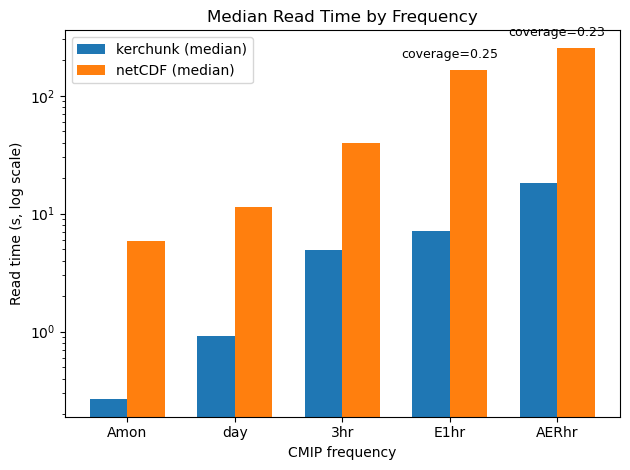

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure frequencies are in a sensible order
freq_order = ["Amon", "day", "3hr", "E1hr", "AERhr"]
df_agg_new = df_agg.set_index("freq").loc[freq_order].reset_index()


x = np.arange(len(df_agg_new))
width = 0.35

fig, ax = plt.subplots()

ax.bar(
    x - width / 2,
    df_agg_new["kerchunk_median"],
    width,
    label="kerchunk (median)",
)

ax.bar(
    x + width / 2,
    df_agg_new["netcdf_median"],
    width,
    label="netCDF (median)",
)

ax.set_xticks(x)
ax.set_xticklabels(df_agg_new["freq"])
ax.set_yscale("log")

ax.set_ylabel("Read time (s, log scale)")
ax.set_xlabel("CMIP frequency")
ax.set_title("Median Read Time by Frequency")

ax.legend()

# Annotate bars with coverage if less than 1.0
for i, row in df_agg_new.iterrows():
    if row["coverage"] < 1.0:
        y = max(row["kerchunk_median"], row["netcdf_median"]) * 1.2
        ax.text(
            i,
            y,
            f"coverage={row['coverage']:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

**Key observations:**

- Median netCDF read time increases sharply with temporal frequency, spanning more than an order of magnitude.
- Median kerchunk read time increases more gradually across the same frequencies.
- The performance gap between netCDF and kerchunk widens at higher temporal resolutions.
- Frequencies with incomplete sampling are annotated with coverage values.

**Takeaway:**
Across CMIP frequencies, netCDF read performance degrades rapidly as temporal resolution increases, while kerchunk scales more favorably, yielding a growing performance advantage at higher frequencies.


## Overall takeaway

- NetCDF read time degrades rapidly with increasing dataset fragmentation and temporal frequency, spanning multiple orders of magnitude.
- Kerchunk read time scales much more favorably and shows weak sensitivity to file count.
- As temporal frequency increases (monthly → daily → sub-daily), the performance gap between kerchunk and netCDF widens.
- File count is the primary driver of netCDF performance degradation, while kerchunk variability is driven mainly by metadata and reference complexity.

Overall, these results show that kerchunk effectively decouples read performance from dataset fragmentation, making it well suited for large, highly fragmented CMIP-style datasets.
